# Blend in Linear vs Gamma

A flat black square with a 50%-opacity white circle (with a black outline so its edge is
visible on its own) shows why we typically want to blend with linear light as opposed to the
gamma-encoded version:

- **Linear blend** (`composition_blend_alpha`): decodes both layers to linear light, averages,
  then re-encodes for display.
- **Gamma blend** (`composition_nonlinear_r_g_b_blend_alpha`): averages the gamma-encoded values
  directly, without linearizing first.

The circle is a single flat color, so each blend produces one uniform gray disc -- no texture or
antialiasing noise to distract from the comparison. The two discs come out clearly different
brightnesses, and the difference image is a solid, uniform disc rather than noise. The square
and circle layers are also exported on their own as standalone assets.

In [1]:
import brushcue
from IPython.display import Image, display

ASSETS_DIR = "/home/dito/dev/monorepo/writing/graphics/chapters/numbers/assets"

ctx = brushcue.Context()

new pipeline: painter_Tessellated_fill_solid_no_brush_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_18030370004436334972_inarr_false


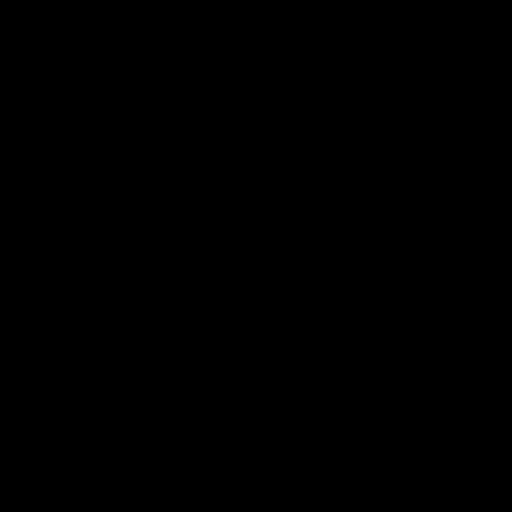

new pipeline: painter_Elliptical_fill_solid_brush_solid_sample_true_rgba16float


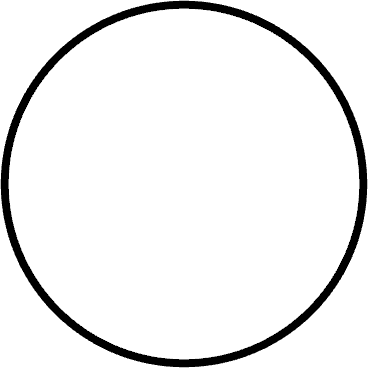

new pipeline: color_transformer_shader_rgba16float_compute_18147521187885925800_inarr_false
new pipeline: blend_Alpha_rgba16float_compute_bg_false_fg_false
new pipeline: color_transformer_shader_rgba16float_compute_13509697929820575703_inarr_false


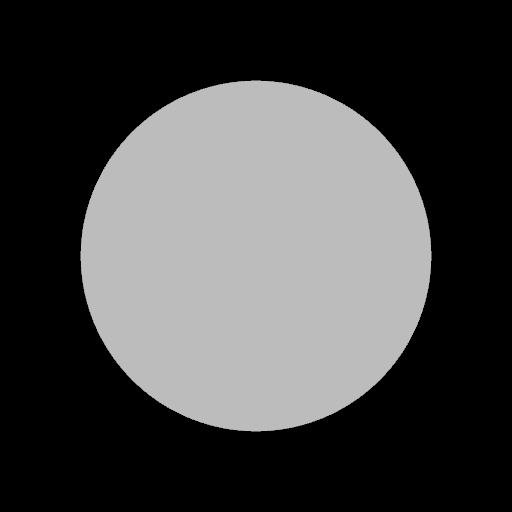

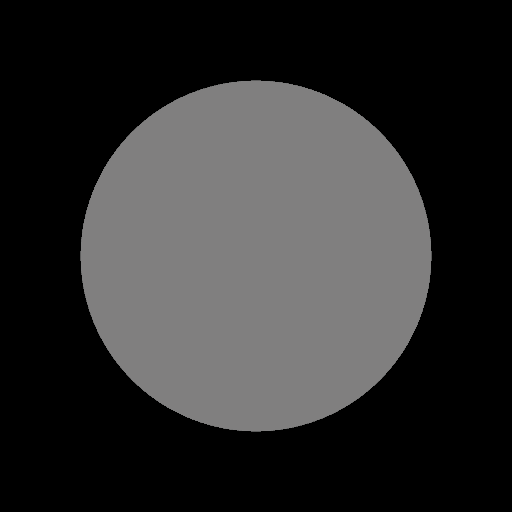

new pipeline: color_transformer_shader_rgba16float_compute_10540239407552119869_inarr_false
new pipeline: color_transformer_shader_rgba16float_compute_2206609067086327257_inarr_false
new pipeline: blend_Subtract_rgba16float_compute_bg_false_fg_false
new pipeline: color_transformer_shader_rgba16float_compute_16861657794771480865_inarr_false


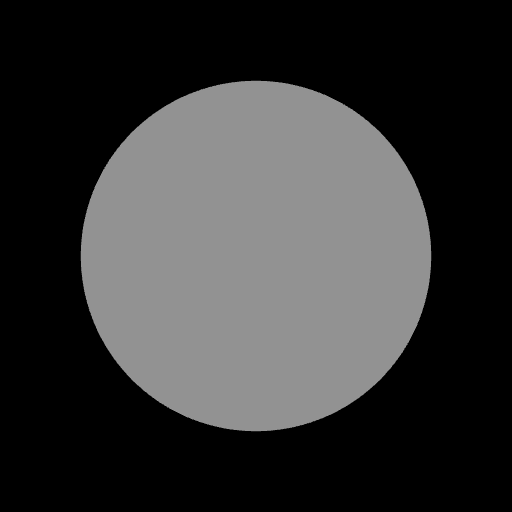

In [2]:
SQUARE_SIZE = 512.0
DIAMETER = SQUARE_SIZE * 0.7
OUTLINE_RADIUS = 4.0
ORIGIN = brushcue.point2f_from_components(0, 0)

def make_solid_square(size: float, color: tuple):
    painter = brushcue.painter_new()
    color_graph = brushcue.profiled_color_from_rgba_srgb(
        brushcue.r_g_b_a_color_constant(color[0], color[1], color[2], 1.0)
    )
    render_style = brushcue.render_style_fill_only(brushcue.fill_solid(color_graph))
    painter = brushcue.painter_add_rectangle_with_render_style(
        painter,
        ORIGIN,
        brushcue.vector2f_constant(size, size),
        0,
        render_style,
        brushcue.transform2_to_list(brushcue.transform2_identity())
    )
    return brushcue.composition_painter(painter)

def make_circle(diameter: float, opacity: float, outline_radius: float):
    painter = brushcue.painter_new()
    fill_color = brushcue.profiled_color_from_rgba_srgb(
        brushcue.r_g_b_a_color_constant(1, 1, 1, opacity)
    )
    outline_color = brushcue.profiled_color_from_rgba_srgb(
        brushcue.r_g_b_a_color_constant(0, 0, 0, 1.0)
    )
    brush = brushcue.brush_solid(outline_color, outline_radius)
    render_style = brushcue.render_style_brush_and_fill(brush, brushcue.fill_solid(fill_color))
    painter = brushcue.painter_add_ellipse_with_render_style(
        painter,
        ORIGIN,
        brushcue.vector2f_constant(diameter, diameter),
        0,
        render_style,
        brushcue.transform2_to_list(brushcue.transform2_identity())
    )
    return brushcue.composition_painter(painter)

# Both shapes are centered on the same origin point, so the circle lands in the
# middle of the square once composited.
black_square = make_solid_square(SQUARE_SIZE, (0, 0, 0))
white_circle = make_circle(DIAMETER, 0.5, OUTLINE_RADIUS)

# Export the two layers on their own (transparent background for the circle) so
# they can be reused as standalone assets.
black_square_bytes = black_square.execute(ctx).as_composition().to_image_bytes(ctx)
black_square_path = f"{ASSETS_DIR}/circle_blend_black_square.png"
with open(black_square_path, "wb") as f:
    f.write(black_square_bytes)
display(Image(black_square_path))

white_circle_bytes = white_circle.execute(ctx).as_composition().to_image_bytes(ctx)
white_circle_path = f"{ASSETS_DIR}/circle_blend_white_circle.png"
with open(white_circle_path, "wb") as f:
    f.write(white_circle_bytes)
display(Image(white_circle_path))

circle_transform = brushcue.transform2_identity()
circle_blend_linear = brushcue.composition_blend_alpha(
    white_circle,
    black_square,
    circle_transform
)
circle_blend_linear_bytes = circle_blend_linear.execute(ctx).as_composition().to_image_bytes(ctx)
circle_blend_linear_path = f"{ASSETS_DIR}/circle_blend_linear.png"
with open(circle_blend_linear_path, "wb") as f:
    f.write(circle_blend_linear_bytes)
display(Image(circle_blend_linear_path))

circle_blend_gamma = brushcue.composition_nonlinear_r_g_b_blend_alpha(
    white_circle,
    black_square,
    circle_transform
)
circle_blend_gamma_bytes = circle_blend_gamma.execute(ctx).as_composition().to_image_bytes(ctx)
circle_blend_gamma_path = f"{ASSETS_DIR}/circle_blend_gamma.png"
with open(circle_blend_gamma_path, "wb") as f:
    f.write(circle_blend_gamma_bytes)
display(Image(circle_blend_gamma_path))

circle_diff = brushcue.composition_blend_subtract(circle_blend_linear, circle_blend_gamma, brushcue.transform2_identity())
circle_diff_bytes = circle_diff.execute(ctx).as_composition().to_image_bytes(ctx)
circle_diff_path = f"{ASSETS_DIR}/circle_blend_diff.png"
with open(circle_diff_path, "wb") as f:
    f.write(circle_diff_bytes)
display(Image(circle_diff_path))